# Crochet Pattern Diagram → JSON  
### Pure CV + ML pipeline (no external APIs)

**Pipeline overview**
```
Image
  └─ 1. Preprocessing      (denoise, binarize, deskew)
       └─ 2. ROI detection   (find the stitch grid region)
            └─ 3. Grid segmentation (row/column boundaries)
                 └─ 4. Cell classification  ← THREE APPROACHES:
                 │       A) Template matching  (baseline)
                 │       B) HOG + SVM          (classic ML)
                 │       C) Tiny CNN           (deep learning)
                 └─ 5. JSON assembly  →  6. Redraw diagram
```

All training data is **synthetically generated** — no manual labelling needed.

In [46]:
%pip install opencv-python-headless scikit-image scikit-learn torch torchvision matplotlib numpy scipy pillow tqdm --quiet

Note: you may need to restart the kernel to use updated packages.


In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc
import json, os, random, copy
from pathlib import Path
from scipy import ndimage, signal
from scipy.ndimage import label as scipy_label
from skimage.feature import hog
from skimage.transform import resize as sk_resize
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from PIL import Image, ImageDraw
try:
    from tqdm.notebook import tqdm
    _ = tqdm([], desc="")  # triggers widget check
except Exception:
    from tqdm import tqdm  # plain text fallback

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as T

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f'PyTorch device: {DEVICE}')

Exception ignored in: <function tqdm.__del__ at 0x14c6d4400>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/crochet_pr/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/opt/anaconda3/envs/crochet_pr/lib/python3.11/site-packages/tqdm/notebook.py", line 280, in close
    self.disp(bar_style='success', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


PyTorch device: mps


---
## Part 1 — Image Preprocessing

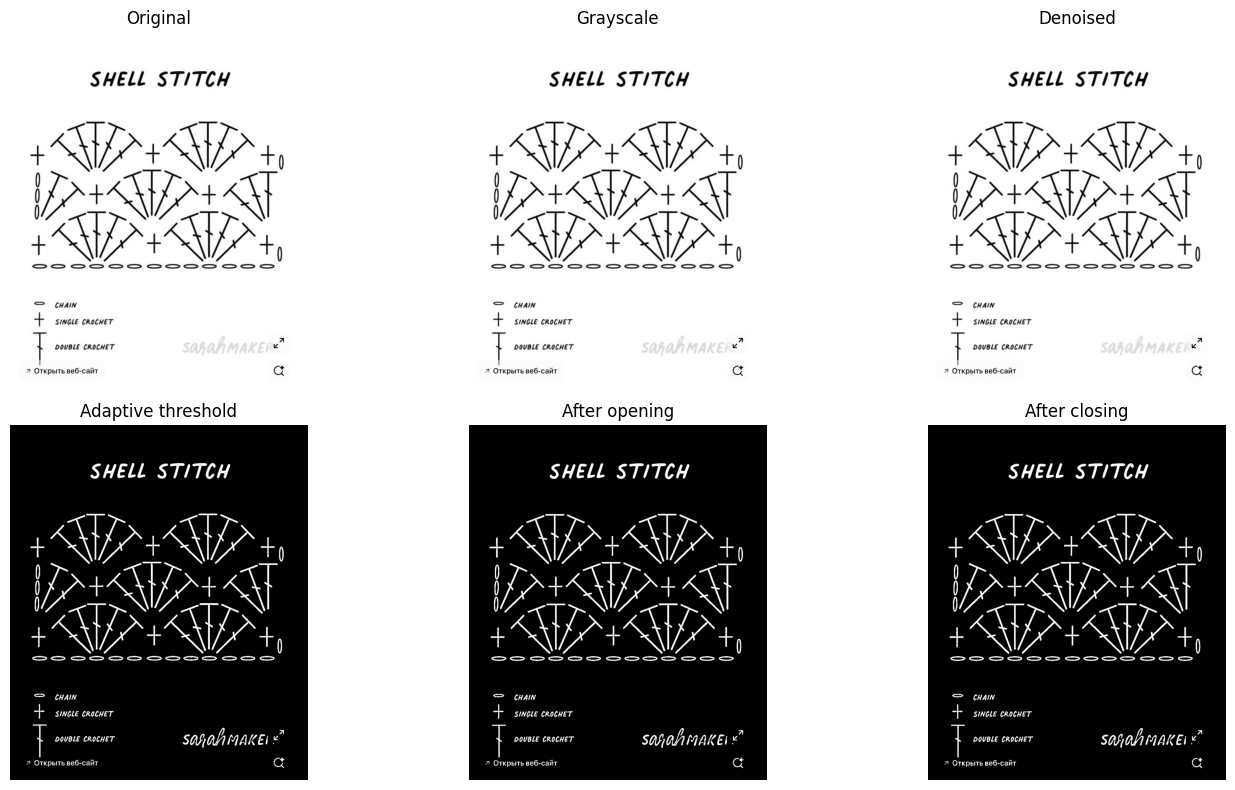

Image shape: (1538, 1288, 3)


In [48]:
# ── helpers ────────────────────────────────────────────────────────────────
def load_image(path: str) -> np.ndarray:
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def preprocess(img_rgb: np.ndarray) -> dict:
    """
    Returns a dict with intermediate images at each preprocessing stage.
    Binary image: foreground (ink) = 255, background = 0.
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # 1. Denoise
    denoised = cv2.fastNlMeansDenoising(gray, h=10, templateWindowSize=7,
                                         searchWindowSize=21)

    # 2. Adaptive threshold (handles uneven lighting in phone photos)
    binary = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=19, C=4
    )

    # 3. Remove tiny noise with morphological opening
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

    # 4. Close small gaps inside symbols
    kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    closed = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel2, iterations=1)

    return dict(gray=gray, denoised=denoised, binary=binary,
                cleaned=cleaned, closed=closed)


def show_preprocessing(img_rgb, stages):
    keys = ['gray', 'denoised', 'binary', 'cleaned', 'closed']
    titles = ['Grayscale', 'Denoised', 'Adaptive threshold',
              'After opening', 'After closing']
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes[0, 0].imshow(img_rgb); axes[0, 0].set_title('Original')
    for ax, k, t in zip(axes.flat[1:], keys, titles):
        ax.imshow(stages[k], cmap='gray'); ax.set_title(t)
    for ax in axes.flat:
        ax.axis('off')
    plt.tight_layout(); plt.show()


# ── Run ────────────────────────────────────────────────────────────────────
IMAGE_PATH = 'data/raw/easy/39.png'   # ← change to your image

img_rgb = load_image(IMAGE_PATH)
stages  = preprocess(img_rgb)
show_preprocessing(img_rgb, stages)
print('Image shape:', img_rgb.shape)

## Part 2 — ROI Detection (find the stitch grid)

Phone photos of pattern books contain margins, text, and page numbers.  
We isolate the **main stitch grid** before classification.

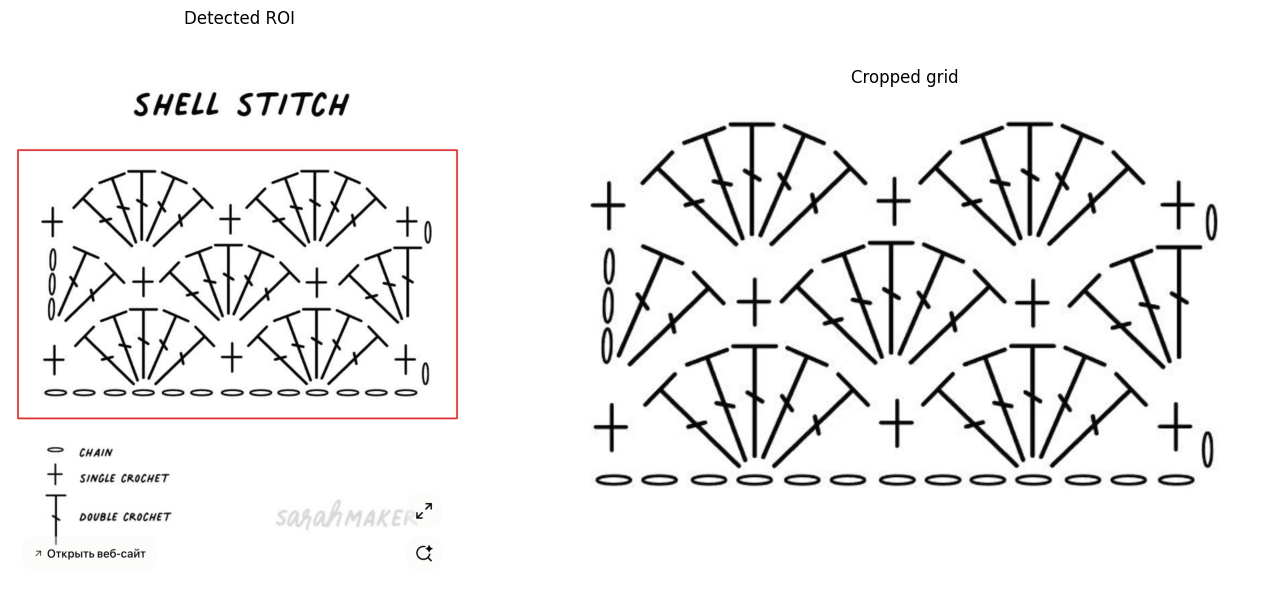

ROI: (22, 331, 1232, 753)


In [49]:
def find_stitch_roi(binary: np.ndarray,
                    min_fill_ratio: float = 0.05,
                    margin_frac: float = 0.02) -> tuple[int,int,int,int]:
    """
    Locate the bounding box of the densest connected region (the stitch grid).
    Returns (x, y, w, h) in pixel coordinates.

    Strategy
    --------
    1. Dilate heavily so nearby symbols merge into blobs.
    2. Find the largest blob by area — that is the stitch grid.
    3. Return its bounding rectangle with a small margin.
    """
    # Dilate so all stitch symbols within a piece connect
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 20))
    dilated = cv2.dilate(binary, k, iterations=3)

    # Find contours of merged blobs
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        h, w = binary.shape
        return 0, 0, w, h

    # Pick the largest contour
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)

    # Add margin
    H, W = binary.shape
    mx = int(W * margin_frac)
    my = int(H * margin_frac)
    x = max(0, x - mx);  y = max(0, y - my)
    w = min(W - x, w + 2*mx)
    h = min(H - y, h + 2*my)
    return x, y, w, h


def crop_roi(img_rgb, binary, roi):
    x, y, w, h = roi
    return img_rgb[y:y+h, x:x+w], binary[y:y+h, x:x+w]


roi = find_stitch_roi(stages['closed'])
roi_rgb, roi_bin = crop_roi(img_rgb, stages['closed'], roi)

# Visualise
vis = img_rgb.copy()
x,y,w,h = roi
cv2.rectangle(vis, (x,y), (x+w,y+h), (220,50,50), 4)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(vis);     axes[0].set_title('Detected ROI'); axes[0].axis('off')
axes[1].imshow(roi_rgb); axes[1].set_title('Cropped grid'); axes[1].axis('off')
plt.tight_layout(); plt.show()
print(f'ROI: {roi}')

## Part 3 — Symbol Detection

Instead of projection profiling, we **detect individual symbols directly** using connected components.

**Strategy:**
1. Dilate slightly so broken strokes of the same symbol merge into one blob.
2. Find all connected components and filter by area + aspect ratio.
3. Cluster detected symbol centres by y-coordinate into **rows**.
4. Within each row sort left-to-right to get **columns**.
5. Fill a 2-D grid — missing positions stay `'empty'`.

This is much more robust than grid projection when symbols are irregularly spaced.


Detected 40 symbol candidates
Grid layout: 6 rows × 13 cols
Median symbol size: 93px tall × 71px wide


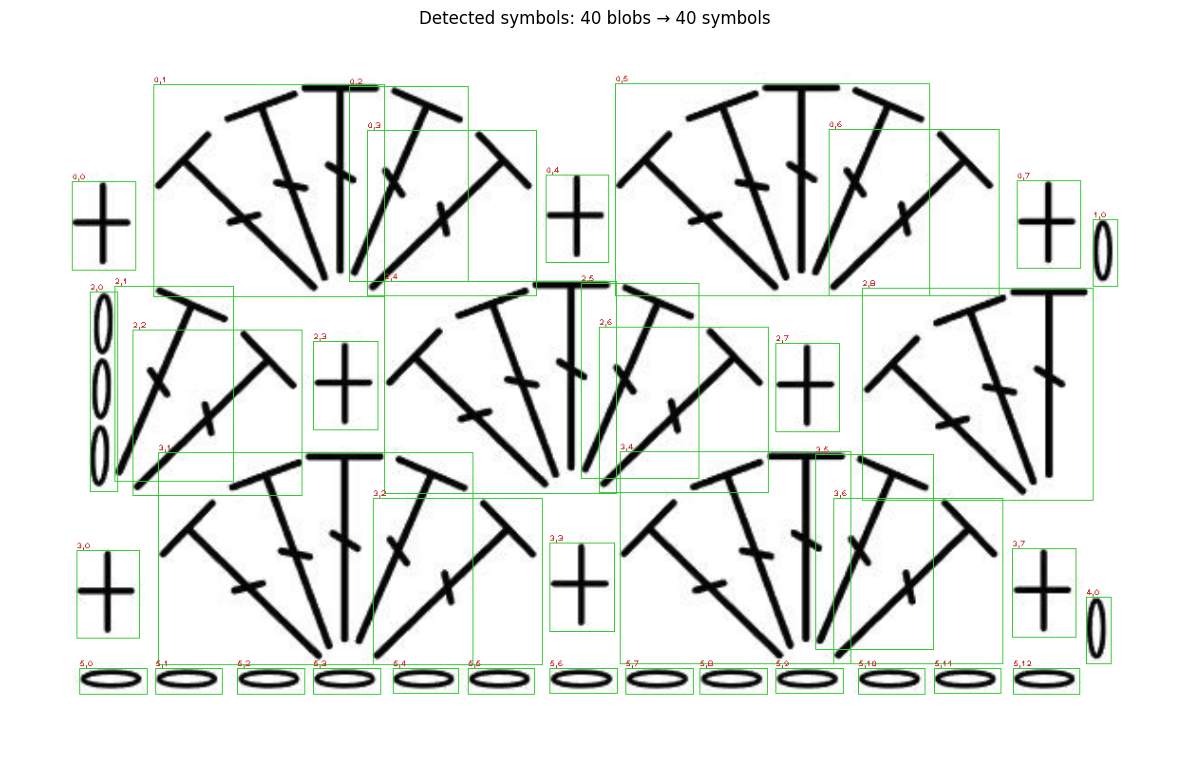

In [50]:
def detect_symbol_candidates(
        binary_roi: np.ndarray,
        dilation_px: int = 4,
        min_area: int = 40,
        max_area_frac: float = 0.04,
        min_aspect: float = 0.12,
        max_aspect: float = 7.0) -> list[dict]:
    """
    Detect individual stitch symbols as bounding boxes via connected components.

    Parameters
    ----------
    binary_roi    : binary image (foreground=255) already cropped to ROI
    dilation_px   : kernel radius for merging broken strokes
    min_area      : minimum component area in pixels (noise filter)
    max_area_frac : components larger than this fraction of the image are skipped
    min/max_aspect: width/height ratio filter

    Returns list of dicts with keys: x, y, w, h, cx, cy, area
    """
    H, W = binary_roi.shape
    max_area = H * W * max_area_frac

    # Dilate to reconnect broken strokes of the same symbol
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilation_px, dilation_px))
    dilated = cv2.dilate(binary_roi, k, iterations=2)

    # Connected components (on dilated image to merge strokes)
    num_labels, _, stats, centroids = cv2.connectedComponentsWithStats(
        dilated, connectivity=8)

    boxes = []
    for i in range(1, num_labels):          # skip background label 0
        area   = int(stats[i, cv2.CC_STAT_AREA])
        x      = int(stats[i, cv2.CC_STAT_LEFT])
        y      = int(stats[i, cv2.CC_STAT_TOP])
        w      = int(stats[i, cv2.CC_STAT_WIDTH])
        h      = int(stats[i, cv2.CC_STAT_HEIGHT])
        cx, cy = float(centroids[i][0]), float(centroids[i][1])
        aspect = w / max(h, 1)

        if (min_area <= area <= max_area
                and min_aspect <= aspect <= max_aspect):
            boxes.append(dict(x=x, y=y, w=w, h=h, cx=cx, cy=cy, area=area))

    return boxes


def snap_to_grid(
        boxes: list[dict],
        row_tol_frac: float = 0.55
) -> tuple[list[tuple[int, int, dict]], float, float]:
    """
    Assign each detected symbol a (row_idx, col_idx) grid position.

    Algorithm
    ---------
    1. Estimate typical symbol height/width from medians.
    2. Sort symbols by y-centre; greedily merge into rows when the
       y distance to the current row mean is within row_tol_frac * med_h.
    3. Within each row sort by x-centre → column index.

    Returns
    -------
    positions : list of (row_idx, col_idx, box)
    med_h, med_w : median symbol dimensions (used for cropping)
    """
    if not boxes:
        return [], 32, 32

    med_h = float(np.median([b['h'] for b in boxes]))
    med_w = float(np.median([b['w'] for b in boxes]))
    tol   = med_h * row_tol_frac

    # Sort all symbols top-to-bottom
    sorted_idx = sorted(range(len(boxes)), key=lambda i: boxes[i]['cy'])

    # Greedy row grouping
    rows: list[list[int]] = []        # each entry is a list of box indices
    row_means: list[float] = []       # running mean cy for each row

    for idx in sorted_idx:
        cy = boxes[idx]['cy']
        placed = False
        for ri, mean_cy in enumerate(row_means):
            if abs(cy - mean_cy) <= tol:
                rows[ri].append(idx)
                # Update running mean
                row_means[ri] = np.mean([boxes[j]['cy'] for j in rows[ri]])
                placed = True
                break
        if not placed:
            rows.append([idx])
            row_means.append(cy)

    # Sort rows top-to-bottom
    rows.sort(key=lambda row: np.mean([boxes[j]['cy'] for j in row]))

    # Build final (row_idx, col_idx, box) list
    positions = []
    for ri, row in enumerate(rows):
        row_sorted = sorted(row, key=lambda j: boxes[j]['cx'])
        for ci, j in enumerate(row_sorted):
            positions.append((ri, ci, boxes[j]))

    return positions, med_h, med_w


# ── Visualise symbol detection ────────────────────────────────────────────
boxes = detect_symbol_candidates(roi_bin)
positions, med_h, med_w = snap_to_grid(boxes)

print(f'Detected {len(boxes)} symbol candidates')
if positions:
    max_row = max(ri for ri, ci, _ in positions) + 1
    max_col = max(ci for ri, ci, _ in positions) + 1
    print(f'Grid layout: {max_row} rows × {max_col} cols')
    print(f'Median symbol size: {med_h:.0f}px tall × {med_w:.0f}px wide')

# Draw bounding boxes on the ROI
vis_det = roi_rgb.copy()
for ri, ci, b in positions:
    x, y, w, h = b['x'], b['y'], b['w'], b['h']
    cv2.rectangle(vis_det, (x, y), (x+w, y+h), (50, 200, 50), 1)
    cv2.putText(vis_det, f'{ri},{ci}', (x, max(0, y-2)),
                cv2.FONT_HERSHEY_PLAIN, 0.55, (200, 50, 50), 1)

plt.figure(figsize=(12, 8))
plt.imshow(vis_det)
plt.title(f'Detected symbols: {len(boxes)} blobs → {len(positions)} symbols')
plt.axis('off')
plt.tight_layout()
plt.show()


## Part 4 — Synthetic Training Data Generation

We **draw** stitch symbols programmatically to create training images.  
Each symbol is rendered with random augmentations (scale, rotation, stroke width, noise) to simulate real photos.

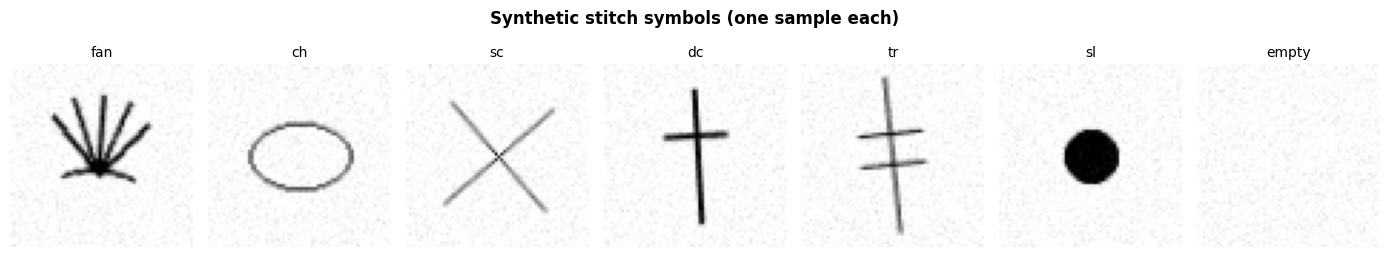

In [51]:
CELL_PX = 64   # output cell size for classification

STITCH_TYPES = ['fan', 'ch', 'sc', 'dc', 'tr', 'sl', 'empty']


def _canvas(size=CELL_PX) -> tuple[np.ndarray, ImageDraw.Draw]:
    img = Image.new('L', (size, size), color=255)  # white background
    return img, ImageDraw.Draw(img)


def _add_augmentation(img: Image.Image,
                       angle_range=8, scale_range=(0.82, 1.18),
                       noise_std=8) -> np.ndarray:
    """Random rotation + scale + Gaussian noise → numpy uint8."""
    angle = random.uniform(-angle_range, angle_range)
    scale = random.uniform(*scale_range)
    new_sz = max(16, int(CELL_PX * scale))
    img = img.rotate(angle, fillcolor=255, resample=Image.BILINEAR)
    img = img.resize((new_sz, new_sz), Image.BILINEAR)
    # Centre-crop or pad back to CELL_PX
    out = Image.new('L', (CELL_PX, CELL_PX), 255)
    offset = ((CELL_PX - new_sz) // 2, (CELL_PX - new_sz) // 2)
    out.paste(img, offset)
    arr = np.array(out, dtype=np.float32)
    arr += np.random.normal(0, noise_std, arr.shape)
    return np.clip(arr, 0, 255).astype(np.uint8)


# ── Individual stitch drawers ──────────────────────────────────────────────
def _draw_fan(lw_mult=1.0) -> Image.Image:
    img, draw = _canvas()
    cx, cy = CELL_PX // 2, CELL_PX // 2
    n = random.choice([5, 6, 7])
    r = int(CELL_PX * 0.38)
    lw = max(1, int(random.uniform(1.2, 2.5) * lw_mult))
    for angle in np.linspace(-55, 55, n):
        rad = np.radians(angle)
        ex = int(cx + r * np.sin(rad))
        ey = int(cy - r * np.cos(rad))
        draw.line([(cx, cy + r // 3), (ex, ey)], fill=0, width=lw)
    # base arc approximated by ellipse arc
    bw = int(CELL_PX * 0.5)
    bh = int(CELL_PX * 0.18)
    draw.arc([cx - bw//2, cy + r//4, cx + bw//2, cy + r//4 + bh],
             start=200, end=340, fill=0, width=lw)
    return img


def _draw_ch(lw_mult=1.0) -> Image.Image:
    img, draw = _canvas()
    cx, cy = CELL_PX // 2, CELL_PX // 2
    rx = int(CELL_PX * 0.28)
    ry = int(CELL_PX * 0.18)
    lw = max(1, int(random.uniform(1.2, 2.5) * lw_mult))
    draw.ellipse([cx - rx, cy - ry, cx + rx, cy + ry], outline=0, width=lw)
    return img


def _draw_sc(lw_mult=1.0) -> Image.Image:
    img, draw = _canvas()
    cx, cy = CELL_PX // 2, CELL_PX // 2
    d = int(CELL_PX * 0.28)
    lw = max(1, int(random.uniform(1.5, 3.0) * lw_mult))
    draw.line([(cx - d, cy - d), (cx + d, cy + d)], fill=0, width=lw)
    draw.line([(cx - d, cy + d), (cx + d, cy - d)], fill=0, width=lw)
    return img


def _draw_dc(lw_mult=1.0) -> Image.Image:
    img, draw = _canvas()
    cx, cy = CELL_PX // 2, CELL_PX // 2
    half_h = int(CELL_PX * 0.38)
    half_cb = int(CELL_PX * 0.18)
    lw = max(1, int(random.uniform(1.5, 2.5) * lw_mult))
    draw.line([(cx, cy - half_h), (cx, cy + half_h)], fill=0, width=lw)
    y_cb = cy - half_h // 3
    draw.line([(cx - half_cb, y_cb), (cx + half_cb, y_cb)], fill=0, width=lw)
    return img


def _draw_tr(lw_mult=1.0) -> Image.Image:
    img, draw = _canvas()
    cx, cy = CELL_PX // 2, CELL_PX // 2
    half_h = int(CELL_PX * 0.40)
    half_cb = int(CELL_PX * 0.16)
    lw = max(1, int(random.uniform(1.5, 2.5) * lw_mult))
    draw.line([(cx, cy - half_h), (cx, cy + half_h)], fill=0, width=lw)
    for offset in [-half_h // 4, half_h // 8]:
        draw.line([(cx - half_cb, cy + offset),
                    (cx + half_cb, cy + offset)], fill=0, width=lw)
    return img


def _draw_sl(lw_mult=1.0) -> Image.Image:
    img, draw = _canvas()
    cx, cy = CELL_PX // 2, CELL_PX // 2
    r = int(CELL_PX * 0.16)
    draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=0)
    return img


def _draw_empty(lw_mult=1.0) -> Image.Image:
    img, _ = _canvas()   # just white
    return img


DRAW_FN = dict(fan=_draw_fan, ch=_draw_ch, sc=_draw_sc,
               dc=_draw_dc, tr=_draw_tr, sl=_draw_sl, empty=_draw_empty)


def generate_samples(stitch_type: str, n: int = 500,
                     lw_range=(0.7, 1.4)) -> np.ndarray:
    """Generate N augmented images for one stitch type. Returns (N, H, W) uint8."""
    fn = DRAW_FN[stitch_type]
    imgs = []
    for _ in range(n):
        lw = random.uniform(*lw_range)
        base = fn(lw_mult=lw)
        aug  = _add_augmentation(base)
        imgs.append(aug)
    return np.stack(imgs)   # (N, 64, 64)


# ── Visualise one sample per class ────────────────────────────────────────
fig, axes = plt.subplots(1, len(STITCH_TYPES), figsize=(14, 2.5))
for ax, stype in zip(axes, STITCH_TYPES):
    sample = generate_samples(stype, n=1)[0]
    ax.imshow(sample, cmap='gray', vmin=0, vmax=255)
    ax.set_title(stype, fontsize=10)
    ax.axis('off')
plt.suptitle('Synthetic stitch symbols (one sample each)', y=1.02, fontweight='bold')
plt.tight_layout(); plt.show()

In [52]:
# ── Build full dataset ─────────────────────────────────────────────────────
N_PER_CLASS = 600

X_all, y_all = [], []
for stype in tqdm(STITCH_TYPES, desc='Generating'):
    imgs = generate_samples(stype, n=N_PER_CLASS)
    X_all.append(imgs)
    y_all.extend([stype] * N_PER_CLASS)

X_all = np.concatenate(X_all, axis=0)   # (N_total, 64, 64) uint8
y_all = np.array(y_all)

le = LabelEncoder().fit(STITCH_TYPES)
y_enc = le.transform(y_all)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_enc, test_size=0.2, stratify=y_enc, random_state=SEED)

print(f'Total samples: {len(X_all)}  |  Train: {len(X_train)}  |  Test: {len(X_test)}')
print('Classes:', list(le.classes_))

Generating: 100%|██████████| 7/7 [00:00<00:00, 11.30it/s]

Total samples: 4200  |  Train: 3360  |  Test: 840
Classes: [np.str_('ch'), np.str_('dc'), np.str_('empty'), np.str_('fan'), np.str_('sc'), np.str_('sl'), np.str_('tr')]


---
## Part 5A — Approach A: Template Matching (Baseline)

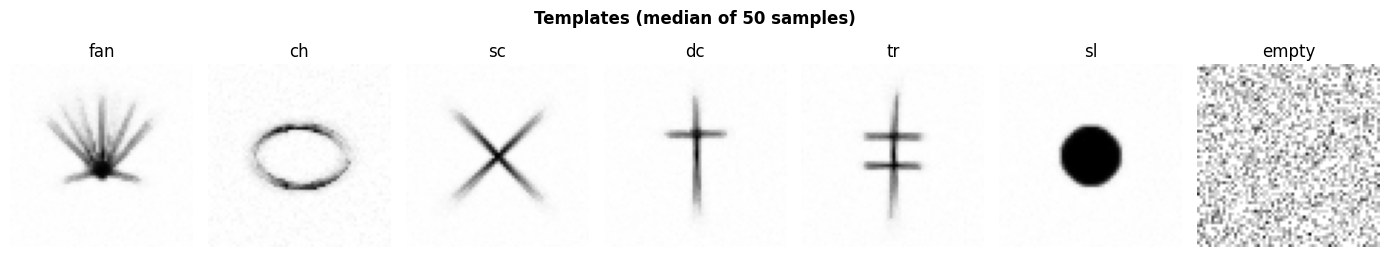

Template matching: 100%|██████████| 840/840 [00:00<00:00, 2264.15it/s]


Template Matching — Classification Report
              precision    recall  f1-score   support

          ch       0.84      0.97      0.90       120
          dc       0.88      0.90      0.89       120
       empty       1.00      0.24      0.39       120
         fan       0.93      1.00      0.96       120
          sc       0.86      1.00      0.93       120
          sl       0.90      1.00      0.94       120
          tr       0.80      0.98      0.88       120

    accuracy                           0.87       840
   macro avg       0.89      0.87      0.84       840
weighted avg       0.89      0.87      0.84       840



In [53]:
# Build one template per class (median of many samples for robustness)
templates = {}
for stype in STITCH_TYPES:
    samples = generate_samples(stype, n=50)
    templates[stype] = np.median(samples, axis=0).astype(np.uint8)

fig, axes = plt.subplots(1, len(STITCH_TYPES), figsize=(14, 2.5))
for ax, stype in zip(axes, STITCH_TYPES):
    ax.imshow(templates[stype], cmap='gray'); ax.set_title(stype); ax.axis('off')
plt.suptitle('Templates (median of 50 samples)', y=1.02, fontweight='bold')
plt.tight_layout(); plt.show()


def classify_template(cell_gray: np.ndarray) -> str:
    """
    Classify a single cell image using normalized cross-correlation.
    cell_gray: H×W uint8 (grayscale)
    """
    cell_r = cv2.resize(cell_gray, (CELL_PX, CELL_PX))
    best_score, best_class = -np.inf, 'empty'
    for stype, tmpl in templates.items():
        result = cv2.matchTemplate(
            cell_r.astype(np.float32),
            tmpl.astype(np.float32),
            cv2.TM_CCOEFF_NORMED
        )
        score = float(result.max())
        if score > best_score:
            best_score, best_class = score, stype
    return best_class


# Evaluate on test set
y_pred_tmpl = [le.transform([classify_template(X_test[i])])[0]
               for i in tqdm(range(len(X_test)), desc='Template matching')]

print('\nTemplate Matching — Classification Report')
print(classification_report(y_test, y_pred_tmpl, target_names=le.classes_))

## Part 5B — Approach B: HOG Features + SVM

Extracting HOG features…
HOG feature vector size: 1764
Training SVM…

HOG + SVM — Classification Report
              precision    recall  f1-score   support

          ch       1.00      1.00      1.00       120
          dc       1.00      1.00      1.00       120
       empty       1.00      1.00      1.00       120
         fan       1.00      1.00      1.00       120
          sc       1.00      1.00      1.00       120
          sl       1.00      1.00      1.00       120
          tr       1.00      1.00      1.00       120

    accuracy                           1.00       840
   macro avg       1.00      1.00      1.00       840
weighted avg       1.00      1.00      1.00       840



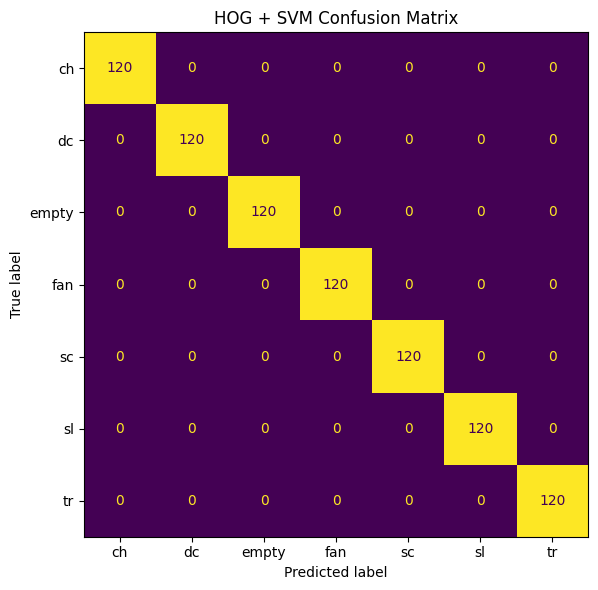

In [54]:
HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    channel_axis=None
)


def extract_hog(images: np.ndarray) -> np.ndarray:
    """images: (N, H, W) uint8  →  (N, feat_dim) float"""
    feats = []
    for img in images:
        norm = img.astype(np.float32) / 255.0
        h = hog(norm, **HOG_PARAMS)
        feats.append(h)
    return np.stack(feats)


print('Extracting HOG features…')
X_hog_train = extract_hog(X_train)
X_hog_test  = extract_hog(X_test)
print(f'HOG feature vector size: {X_hog_train.shape[1]}')

scaler = StandardScaler().fit(X_hog_train)
X_hog_train_s = scaler.transform(X_hog_train)
X_hog_test_s  = scaler.transform(X_hog_test)

print('Training SVM…')
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED)
svm.fit(X_hog_train_s, y_train)

y_pred_svm = svm.predict(X_hog_test_s)
print('\nHOG + SVM — Classification Report')
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm, display_labels=le.classes_, ax=ax, colorbar=False)
ax.set_title('HOG + SVM Confusion Matrix')
plt.tight_layout(); plt.show()

## Part 5C — Approach C: Tiny CNN (PyTorch)

In [55]:
class StitchCNN(nn.Module):
    """
    Lightweight CNN for 64×64 grayscale stitch images.
    Architecture: 3 conv blocks + 2 FC layers.
    ~120 K parameters.
    """
    def __init__(self, n_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),        # 32×32
            nn.Dropout2d(0.20),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),        # 16×16
            nn.Dropout2d(0.25),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),        # 8×8
            nn.Dropout2d(0.30),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def make_tensor_dataset(X: np.ndarray, y: np.ndarray) -> TensorDataset:
    xt = torch.tensor(X[:, None, :, :] / 255.0, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return TensorDataset(xt, yt)


BATCH  = 128
EPOCHS = 20
LR     = 1e-3

train_ds = make_tensor_dataset(X_train, y_train)
test_ds  = make_tensor_dataset(X_test,  y_test)
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

model     = StitchCNN(n_classes=len(STITCH_TYPES)).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')
print(model)

Model parameters: 2,238,695
StitchCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  

Training CNN:  25%|██▌       | 5/20 [00:09<00:27,  1.85s/it]

  Epoch   5 | train loss 0.0003 acc 1.000 | val loss 0.0000 acc 1.000


Training CNN:  50%|█████     | 10/20 [00:18<00:18,  1.83s/it]

  Epoch  10 | train loss 0.0001 acc 1.000 | val loss 0.0000 acc 1.000


Training CNN:  75%|███████▌  | 15/20 [00:27<00:09,  1.88s/it]

  Epoch  15 | train loss 0.0001 acc 1.000 | val loss 0.0000 acc 1.000


Training CNN: 100%|██████████| 20/20 [00:37<00:00,  1.87s/it]

  Epoch  20 | train loss 0.0001 acc 1.000 | val loss 0.0000 acc 1.000


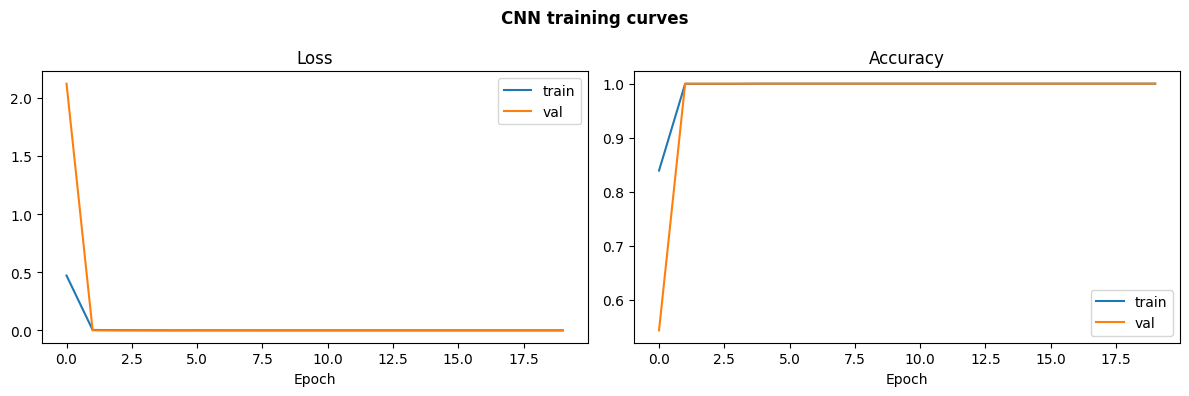

In [56]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += (out.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out  = model(xb)
        loss = criterion(out, yb)
        total_loss += loss.item() * len(yb)
        correct    += (out.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in tqdm(range(1, EPOCHS + 1), desc='Training CNN'):
    tl, ta = train_epoch(model, train_dl, optimizer, criterion)
    vl, va = eval_epoch(model, test_dl, criterion)
    scheduler.step()
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    if epoch % 5 == 0:
        print(f'  Epoch {epoch:3d} | '
              f'train loss {tl:.4f} acc {ta:.3f} | '
              f'val loss {vl:.4f} acc {va:.3f}')

# ── Learning curves ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='train'); ax1.plot(history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history['train_acc'], label='train'); ax2.plot(history['val_acc'], label='val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.suptitle('CNN training curves', fontweight='bold')
plt.tight_layout(); plt.show()

CNN — Classification Report
              precision    recall  f1-score   support

          ch       1.00      1.00      1.00       120
          dc       1.00      1.00      1.00       120
       empty       1.00      1.00      1.00       120
         fan       1.00      1.00      1.00       120
          sc       1.00      1.00      1.00       120
          sl       1.00      1.00      1.00       120
          tr       1.00      1.00      1.00       120

    accuracy                           1.00       840
   macro avg       1.00      1.00      1.00       840
weighted avg       1.00      1.00      1.00       840



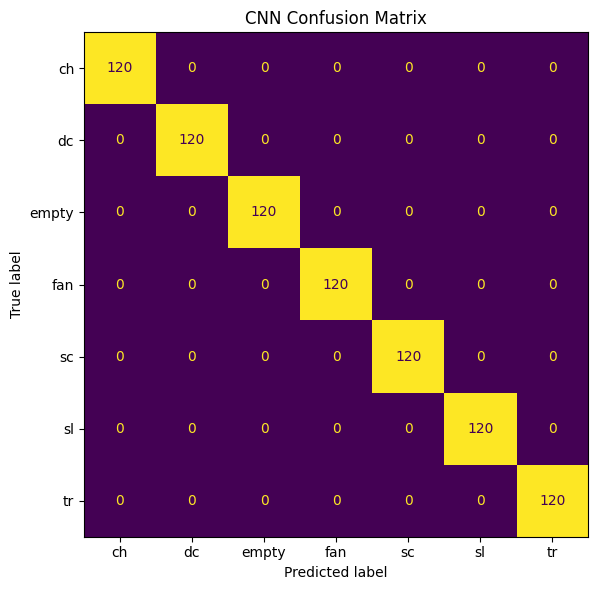

Model saved to crochet_cnn.pth


In [57]:
# ── Full evaluation ────────────────────────────────────────────────────────
@torch.no_grad()
def predict_cnn(model, X: np.ndarray) -> np.ndarray:
    model.eval()
    xt = torch.tensor(X[:, None, :, :] / 255.0, dtype=torch.float32).to(DEVICE)
    preds = []
    for i in range(0, len(xt), 256):
        out = model(xt[i:i+256])
        preds.append(out.argmax(1).cpu().numpy())
    return np.concatenate(preds)


y_pred_cnn = predict_cnn(model, X_test)
print('CNN — Classification Report')
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_cnn, display_labels=le.classes_, ax=ax, colorbar=False)
ax.set_title('CNN Confusion Matrix')
plt.tight_layout(); plt.show()

# Save model
torch.save(model.state_dict(), 'crochet_cnn.pth')
print('Model saved to crochet_cnn.pth')

---
## Part 6 — Classify Every Cell → Assemble JSON

In [58]:
# ── Choose classifier for inference ──────────────────────────────────────
CLASSIFIER = 'cnn'   # 'template' | 'svm' | 'cnn'


def classify_cell(cell_gray: np.ndarray) -> str:
    """
    Classify a single grayscale cell image.
    Internally normalises to CELL_PX × CELL_PX.
    """
    cell_r = cv2.resize(cell_gray, (CELL_PX, CELL_PX))

    if CLASSIFIER == 'template':
        return classify_template(cell_r)

    elif CLASSIFIER == 'svm':
        feat   = extract_hog(cell_r[None])
        feat_s = scaler.transform(feat)
        idx    = svm.predict(feat_s)[0]
        return le.inverse_transform([idx])[0]

    else:  # cnn
        model.eval()
        with torch.no_grad():
            xt  = torch.tensor(cell_r[None, None] / 255.0,
                               dtype=torch.float32).to(DEVICE)
            idx = model(xt).argmax(1).item()
        return le.inverse_transform([idx])[0]


def ink_ratio(cell_gray: np.ndarray, thresh: int = 180) -> float:
    """Fraction of dark pixels — used to quickly skip empty cells."""
    return float((cell_gray < thresh).sum()) / cell_gray.size


def _crop_symbol(roi_gray: np.ndarray,
                  box: dict,
                  med_h: float, med_w: float,
                  pad_frac: float = 0.25) -> np.ndarray:
    """
    Crop a padded square patch centred on the detected bounding box.
    Uses the median symbol dimensions as a minimum size so tiny blobs
    still get enough context.
    """
    H, W = roi_gray.shape
    cx   = int(box['cx'])
    cy   = int(box['cy'])
    half = int(max(box['w'], box['h'], med_w, med_h) / 2 * (1 + pad_frac))
    x0   = max(0, cx - half)
    y0   = max(0, cy - half)
    x1   = min(W, cx + half)
    y1   = min(H, cy + half)
    return roi_gray[y0:y1, x0:x1]


def classify_symbols(
        roi_gray: np.ndarray,
        positions: list[tuple[int, int, dict]],
        med_h: float,
        med_w: float,
        empty_thresh: float = 0.01) -> list[list[str]]:
    """
    Classify each detected symbol and assemble a 2-D grid.

    Parameters
    ----------
    roi_gray   : greyscale ROI
    positions  : output from snap_to_grid — list of (row_idx, col_idx, box)
    med_h/med_w: median symbol dimensions for cropping
    empty_thresh: ink fraction below which a patch is forced to 'empty'

    Returns
    -------
    grid[row][col] = stitch type string ('empty' for missing positions)
    """
    if not positions:
        return []

    n_rows = max(ri for ri, ci, _ in positions) + 1
    n_cols = max(ci for ri, ci, _ in positions) + 1
    grid   = [['empty'] * n_cols for _ in range(n_rows)]

    for ri, ci, box in tqdm(positions, desc='Classifying symbols'):
        patch = _crop_symbol(roi_gray, box, med_h, med_w)
        if patch.size == 0 or ink_ratio(patch) < empty_thresh:
            continue
        grid[ri][ci] = classify_cell(patch)

    return grid


# ── Run on current ROI ────────────────────────────────────────────────────
roi_gray = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2GRAY)
grid = classify_symbols(roi_gray, positions, med_h, med_w)
if grid:
    print(f'Grid classified: {len(grid)} rows × {len(grid[0])} cols')
    for ri, row in enumerate(grid):
        print(f'  row {ri}: {row}')
else:
    print('No symbols detected — check dilation_px / min_area parameters.')


Classifying symbols: 100%|██████████| 40/40 [00:00<00:00, 425.40it/s]

Grid classified: 6 rows × 13 cols
  row 0: [np.str_('tr'), np.str_('sc'), np.str_('sc'), np.str_('fan'), np.str_('tr'), np.str_('fan'), np.str_('fan'), np.str_('tr'), 'empty', 'empty', 'empty', 'empty', 'empty']
  row 1: [np.str_('empty'), 'empty', 'empty', 'empty', 'empty', 'empty', 'empty', 'empty', 'empty', 'empty', 'empty', 'empty', 'empty']
  row 2: [np.str_('sc'), np.str_('sc'), np.str_('sc'), np.str_('tr'), np.str_('sc'), np.str_('empty'), np.str_('sc'), np.str_('tr'), np.str_('sc'), 'empty', 'empty', 'empty', 'empty']
  row 3: [np.str_('tr'), np.str_('empty'), np.str_('empty'), np.str_('tr'), np.str_('empty'), np.str_('empty'), np.str_('empty'), np.str_('tr'), 'empty', 'empty', 'empty', 'empty', 'empty']
  row 4: [np.str_('empty'), 'empty', 'empty', 'empty', 'empty', 'empty', 'empty', 'empty', 'empty', 'empty', 'empty', 'empty', 'empty']
  row 5: [np.str_('ch'), np.str_('ch'), np.str_('ch'), np.str_('fan'), np.str_('ch'), np.str_('ch'), np.str_('ch'), np.str_('ch'), np.str_('ch

In [59]:
# ── Run-length encode one row ──────────────────────────────────────────────
def rle_row(row: list[str]) -> list[dict]:
    """[fan, fan, ch, ch, ch, fan] → [{fan,2},{ch,3},{fan,1}]"""
    if not row:
        return []
    result, cur, cnt = [], row[0], 1
    for s in row[1:]:
        if s == cur:
            cnt += 1
        else:
            result.append({'type': cur, 'count': cnt})
            cur, cnt = s, 1
    result.append({'type': cur, 'count': cnt})
    return result


def grid_to_schema(grid: list[list[str]],
                    title: str = 'Extracted Pattern',
                    piece_label: str = 'Piece 1') -> dict:
    """
    Convert classified grid → JSON schema.
    Rows are numbered from bottom (crochet convention).
    """
    n_rows = len(grid)
    n_cols = max(len(r) for r in grid) if grid else 0

    rows_json = []
    for ri, row in enumerate(reversed(grid)):  # flip: top→bottom becomes row 1→N
        row_num = ri + 1
        stitches = rle_row(row)
        # Skip rows that are entirely empty
        non_empty = [s for s in stitches if s['type'] != 'empty']
        if non_empty:
            rows_json.append({'row_number': row_num, 'stitches': stitches})

    # Infer outline from non-empty cell bounding box
    outline = [[0, 0], [n_cols, 0], [n_cols, n_rows], [0, n_rows]]

    # Collect unique non-empty stitch types
    all_types = {s['type'] for row in grid for s in rle_row(row) if s['type'] != 'empty'}

    LEGEND_DESCS = {
        'fan': 'Fan/shell stitch', 'ch': 'Chain stitch',
        'sc': 'Single crochet',    'dc': 'Double crochet',
        'tr': 'Treble crochet',    'sl': 'Slip stitch',
        'inc': 'Increase',         'dec': 'Decrease',
    }
    legend = {t: LEGEND_DESCS.get(t, t) for t in sorted(all_types)}

    return {
        'schema_type': 'crochet_pattern',
        'title': title,
        'classifier_used': CLASSIFIER,
        'stitch_legend': legend,
        'pieces': [{
            'id': 'piece_1',
            'label': piece_label,
            'outline': outline,
            'rows': rows_json
        }]
    }


schema = grid_to_schema(grid, title=Path(IMAGE_PATH).stem)

JSON_OUT = Path(IMAGE_PATH).stem + '_schema.json'
with open(JSON_OUT, 'w', encoding='utf-8') as f:
    json.dump(schema, f, indent=2, ensure_ascii=False)
print(f'JSON saved to {JSON_OUT}')
print(json.dumps(schema, indent=2, ensure_ascii=False)[:1500], '\n...')

JSON saved to 39_schema.json
{
  "schema_type": "crochet_pattern",
  "title": "39",
  "classifier_used": "cnn",
  "stitch_legend": {
    "ch": "Chain stitch",
    "fan": "Fan/shell stitch",
    "sc": "Single crochet",
    "tr": "Treble crochet"
  },
  "pieces": [
    {
      "id": "piece_1",
      "label": "Piece 1",
      "outline": [
        [
          0,
          0
        ],
        [
          13,
          0
        ],
        [
          13,
          6
        ],
        [
          0,
          6
        ]
      ],
      "rows": [
        {
          "row_number": 1,
          "stitches": [
            {
              "type": "ch",
              "count": 3
            },
            {
              "type": "fan",
              "count": 1
            },
            {
              "type": "ch",
              "count": 5
            },
            {
              "type": "fan",
              "count": 1
            },
            {
              "type": "ch",
              "coun

## Part 7 — Draw Diagram from JSON

Diagram saved → 39_diagram.png


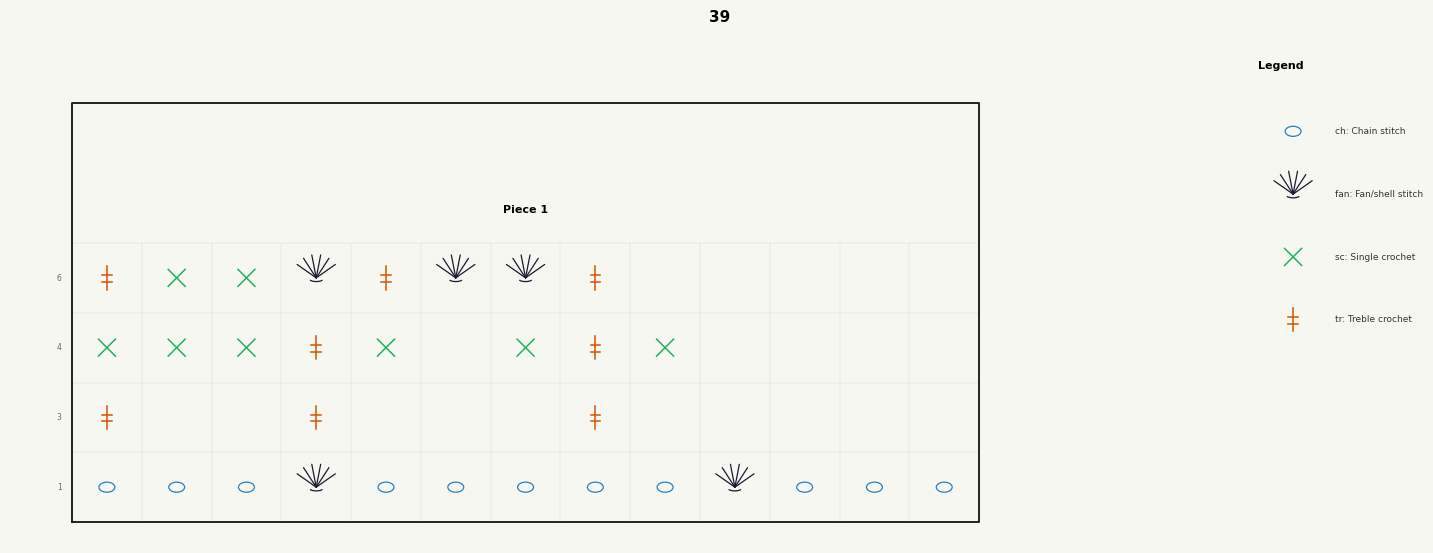

In [60]:
# ── Stitch symbol drawing (matplotlib) ───────────────────────────────────
STITCH_COLOR = {
    'fan':   '#1a1a2e', 'ch':  '#2980b9',
    'sc':    '#27ae60', 'dc':  '#8e44ad',
    'tr':    '#d35400', 'sl':  '#c0392b',
    'inc':   '#16a085', 'dec': '#e67e22',
    'empty': 'none'
}

CELL = 1.0    # grid unit
S    = 0.38   # symbol radius


def sym_fan(ax, cx, cy, color, lw=0.9):
    spokes = np.linspace(-55, 55, 6)
    r = S * 0.88
    for a in spokes:
        rad = np.radians(a)
        ax.plot([cx, cx + r*np.sin(rad)], [cy, cy + r*np.cos(rad)],
                color=color, lw=lw, solid_capstyle='round')
    ax.add_patch(Arc((cx, cy), S*0.6, S*0.28, angle=0,
                     theta1=200, theta2=340, color=color, lw=lw))


def sym_ch(ax, cx, cy, color, lw=0.9):
    ax.add_patch(mpatches.Ellipse((cx,cy), S*0.6, S*0.38,
                                   fill=False, edgecolor=color, lw=lw))


def sym_sc(ax, cx, cy, color, lw=1.1):
    d = S * 0.32
    ax.plot([cx-d, cx+d],[cy-d, cy+d], color=color, lw=lw)
    ax.plot([cx-d, cx+d],[cy+d, cy-d], color=color, lw=lw)


def sym_dc(ax, cx, cy, color, lw=1.1):
    ax.plot([cx, cx],[cy-S*0.44, cy+S*0.44], color=color, lw=lw)
    ax.plot([cx-S*0.2, cx+S*0.2],[cy+S*0.1, cy+S*0.1], color=color, lw=lw)


def sym_tr(ax, cx, cy, color, lw=1.1):
    ax.plot([cx, cx],[cy-S*0.44, cy+S*0.44], color=color, lw=lw)
    for off in [-S*0.15, S*0.1]:
        ax.plot([cx-S*0.18, cx+S*0.18],[cy+off, cy+off], color=color, lw=lw)


def sym_sl(ax, cx, cy, color, lw=1):
    ax.add_patch(plt.Circle((cx,cy), S*0.16, color=color))


def sym_inc(ax, cx, cy, color, lw=1.1):
    d = S*0.28
    ax.plot([cx-d, cx, cx+d],[cy-d, cy+d, cy-d], color=color, lw=lw)


def sym_dec(ax, cx, cy, color, lw=1.1):
    d = S*0.28
    ax.plot([cx-d, cx, cx+d],[cy+d, cy-d, cy+d], color=color, lw=lw)


DRAW = dict(fan=sym_fan, ch=sym_ch, sc=sym_sc, dc=sym_dc,
             tr=sym_tr, sl=sym_sl, inc=sym_inc, dec=sym_dec,
             empty=lambda *a, **k: None)


def expand_stitches(stitches: list[dict]) -> list[str]:
    flat = []
    for s in stitches:
        flat.extend([s['type']] * s.get('count', 1))
    return flat


def draw_schema(schema: dict,
                 out_path: str | None = None,
                 dpi: int = 180,
                 scale: float = 0.5):
    pieces = schema.get('pieces', [])
    if not pieces:
        print('Nothing to draw.'); return

    GAP = 4
    piece_info = []
    for p in pieces:
        rows = p.get('rows', [])
        if rows:
            mc = max(sum(s.get('count',1) for s in r['stitches']) for r in rows)
            nr = len(rows)
        else:
            mc, nr = 1, 1
        piece_info.append((p, mc, nr))

    total_w = sum(mc for _,mc,_ in piece_info) + GAP*(len(pieces)-1) + 2
    total_h = max(nr for _,_,nr in piece_info) + 4

    legend = schema.get('stitch_legend', {})
    legend_w = 14 if legend else 0

    fw = (total_w + legend_w) * scale
    fh = total_h * scale

    fig, ax = plt.subplots(figsize=(max(fw, 8), max(fh, 6)))
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_facecolor('#f7f7f2'); fig.patch.set_facecolor('#f7f7f2')

    cursor_x = 1.0
    for (piece, mc, nr) in piece_info:
        ox, oy = cursor_x, 1.0
        rows = piece.get('rows', [])

        # Grid lines
        for ri in range(nr + 1):
            ax.plot([ox, ox + mc*CELL], [oy + ri*CELL]*2,
                    color='#d8d8d8', lw=0.35, zorder=0)
        for ci in range(mc + 1):
            ax.plot([ox + ci*CELL]*2, [oy, oy + nr*CELL],
                    color='#d8d8d8', lw=0.35, zorder=0)

        # Outline
        outline = piece.get('outline')
        if outline:
            xs = [ox + p[0]*CELL for p in outline] + [ox + outline[0][0]*CELL]
            ys = [oy + p[1]*CELL for p in outline] + [oy + outline[0][1]*CELL]
            ax.plot(xs, ys, color='#222', lw=1.4, zorder=3)

        # Stitches
        sorted_rows = sorted(rows, key=lambda r: r['row_number'])
        for ri, row in enumerate(sorted_rows):
            flat = expand_stitches(row['stitches'])
            col_start = (mc - len(flat)) / 2
            for ci, stype in enumerate(flat):
                cx = ox + (col_start + ci + 0.5)*CELL
                cy = oy + (ri + 0.5)*CELL
                fn  = DRAW.get(stype, DRAW['sc'])
                col = STITCH_COLOR.get(stype, '#333')
                fn(ax, cx, cy, col)

            # Row label
            ax.text(ox - 0.15, oy + (ri+0.5)*CELL,
                    str(row['row_number']),
                    ha='right', va='center', fontsize=5.5, color='#666')

        # Piece label
        label = piece.get('label', piece.get('id',''))
        ax.text(ox + mc*CELL/2, oy + nr*CELL + 0.4, label,
                ha='center', va='bottom', fontsize=8, fontweight='bold')

        cursor_x += mc + GAP

    # Legend
    if legend:
        lx, ly = cursor_x, total_h - 0.5
        ax.text(lx, ly, 'Legend', fontsize=8, fontweight='bold')
        for i, (key, desc) in enumerate(legend.items()):
            fn  = DRAW.get(key, lambda *a, **k: None)
            col = STITCH_COLOR.get(key, '#333')
            fn(ax, lx + 0.5, ly - 0.9*(i+1), col)
            ax.text(lx + 1.1, ly - 0.9*(i+1),
                    f'{key}: {desc}', va='center', fontsize=6.5, color='#333')

    fig.suptitle(schema.get('title','Crochet Pattern'),
                 fontsize=11, fontweight='bold', y=0.98)
    ax.autoscale_view()
    plt.tight_layout()

    if out_path:
        fig.savefig(out_path, dpi=dpi, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f'Diagram saved → {out_path}')
    plt.show()
    return fig


fig = draw_schema(schema, out_path=Path(IMAGE_PATH).stem + '_diagram.png', dpi=200)

## Part 8 — Model Comparison

Model                    Accuracy   F1 (macro)
----------------------------------------------
Template matching          0.8714       0.8430
HOG + SVM                  1.0000       1.0000
Tiny CNN                   1.0000       1.0000


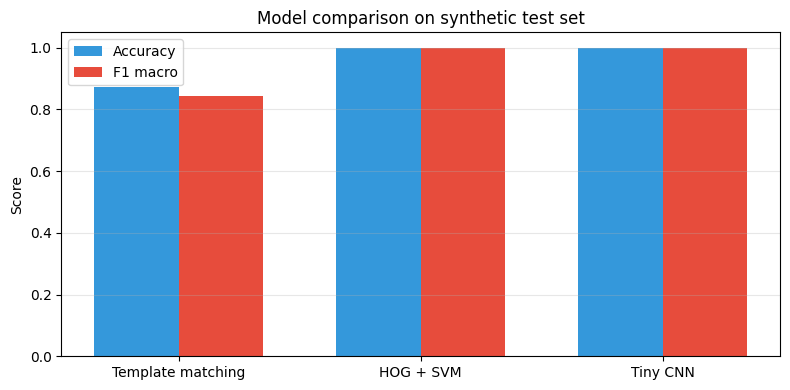

In [61]:
from sklearn.metrics import accuracy_score, f1_score

results = {
    'Template matching': y_pred_tmpl,
    'HOG + SVM':         y_pred_svm,
    'Tiny CNN':          y_pred_cnn,
}

print(f'{"Model":<22} {"Accuracy":>10} {"F1 (macro)":>12}')
print('-' * 46)
for name, preds in results.items():
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro')
    print(f'{name:<22} {acc:>10.4f} {f1:>12.4f}')

# Bar chart
names = list(results.keys())
accs  = [accuracy_score(y_test, p) for p in results.values()]
f1s   = [f1_score(y_test, p, average='macro') for p in results.values()]

x = np.arange(len(names))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, accs, w, label='Accuracy', color='#3498db')
ax.bar(x + w/2, f1s,  w, label='F1 macro',  color='#e74c3c')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Model comparison on synthetic test set')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Part 9 — Full Pipeline (one function)

```python
result = run_pipeline('IMG_1546.jpeg', classifier='cnn')
```

In [62]:
def run_pipeline(image_path: str,
                   classifier: str = 'cnn',
                   save_outputs: bool = True,
                   dilation_px: int = 4) -> dict:
    """
    End-to-end: image → JSON + diagram PNG.

    Parameters
    ----------
    classifier  : 'template' | 'svm' | 'cnn'
    dilation_px : kernel radius for symbol-stroke merging (tune per image)
    """
    global CLASSIFIER
    CLASSIFIER = classifier
    stem = Path(image_path).stem

    print(f'[1/5] Loading & preprocessing {image_path}…')
    img_rgb = load_image(image_path)
    stages  = preprocess(img_rgb)

    print('[2/5] Detecting ROI…')
    roi          = find_stitch_roi(stages['closed'])
    roi_rgb_crop, roi_bin = crop_roi(img_rgb, stages['closed'], roi)
    roi_gray     = cv2.cvtColor(roi_rgb_crop, cv2.COLOR_RGB2GRAY)

    print('[3/5] Detecting individual symbols…')
    boxes = detect_symbol_candidates(roi_bin, dilation_px=dilation_px)
    print(f'      Found {len(boxes)} candidate blobs')
    positions, med_h, med_w = snap_to_grid(boxes)
    if positions:
        nr = max(ri for ri, ci, _ in positions) + 1
        nc = max(ci for ri, ci, _ in positions) + 1
        print(f'      Snapped to {nr} rows × {nc} cols  '
              f'(median symbol {med_h:.0f}×{med_w:.0f}px)')
    else:
        print('      WARNING: no symbols detected — try adjusting dilation_px or min_area')
        return {}

    print(f'[4/5] Classifying symbols with {classifier}…')
    grid = classify_symbols(roi_gray, positions, med_h, med_w)

    print('[5/5] Assembling JSON & drawing…')
    schema = grid_to_schema(grid, title=stem)

    if save_outputs:
        json_path = stem + '_schema.json'
        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(schema, f, indent=2, ensure_ascii=False)
        print(f'JSON  → {json_path}')
        draw_schema(schema, out_path=stem + '_diagram.png', dpi=200)
    else:
        draw_schema(schema)

    return schema


# ── Run ────────────────────────────────────────────────────────────────────
# result = run_pipeline('data/raw/easy/39.png', classifier='cnn')
print('run_pipeline() ready — uncomment above to process your image.')


run_pipeline() ready — uncomment above to process your image.
